In [2]:
import shutil
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from sklearn.manifold import TSNE
from sklearn import preprocessing
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv('tda_payload.csv')
df =data.iloc[: , :-1]
data

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500,label
0,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,0,0,0,0,analysis
1,66,80,83,33,32,53,52,32,66,80,...,0,0,0,0,0,0,0,0,0,analysis
2,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,analysis
3,66,80,83,33,32,56,51,32,66,80,...,0,0,0,0,0,0,0,0,0,analysis
4,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,analysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,worms
79877,71,69,84,32,47,99,103,105,45,98,...,0,0,0,0,0,0,0,0,0,worms
79878,80,79,83,84,32,47,98,108,111,103,...,0,0,0,0,0,0,0,0,0,worms
79879,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,worms


In [5]:
pd.DataFrame(data)

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500,label
0,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,0,0,0,0,analysis
1,66,80,83,33,32,53,52,32,66,80,...,0,0,0,0,0,0,0,0,0,analysis
2,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,analysis
3,66,80,83,33,32,56,51,32,66,80,...,0,0,0,0,0,0,0,0,0,analysis
4,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,analysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,worms
79877,71,69,84,32,47,99,103,105,45,98,...,0,0,0,0,0,0,0,0,0,worms
79878,80,79,83,84,32,47,98,108,111,103,...,0,0,0,0,0,0,0,0,0,worms
79879,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,worms


In [6]:
df

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
0,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,0,0,0,0,0
1,66,80,83,33,32,53,52,32,66,80,...,0,0,0,0,0,0,0,0,0,0
2,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0
3,66,80,83,33,32,56,51,32,66,80,...,0,0,0,0,0,0,0,0,0,0
4,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,0
79877,71,69,84,32,47,99,103,105,45,98,...,0,0,0,0,0,0,0,0,0,0
79878,80,79,83,84,32,47,98,108,111,103,...,0,0,0,0,0,0,0,0,0,0
79879,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,0


In [7]:
y_train = data['label']

In [8]:
y_train.shape

(79881,)

In [9]:
y_train

0        analysis
1        analysis
2        analysis
3        analysis
4        analysis
           ...   
79876       worms
79877       worms
79878       worms
79879       worms
79880       worms
Name: label, Length: 79881, dtype: object

In [10]:
len(df)

79881

In [11]:
# data2 = pd.read_csv('output.csv')
# pd.DataFrame(data2)

In [12]:
inst = []
value_shape = []
for i in range(0, len(df)):
    rows1 = df.iloc[i]
    value_shape.append(np.reshape(rows1.values, (1, 1500)))

In [13]:
df.iloc[0]
value_shape[:10]

[array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]]),
 array([[66, 80, 83, ...,  0,  0,  0]])]

In [14]:
new_data=np.array(value_shape)
new_data.shape

(79881, 1, 1500)

In [15]:
from sklearn.pipeline import Pipeline
from gtda.images import Binarizer
from gtda.images import RadialFiltration
from gtda.diagrams import Amplitude
from gtda.homology import CubicalPersistence
from gtda.diagrams import Scaler
steps = [
    ("binarizer", Binarizer(threshold=0.4)),
    ("filtration", RadialFiltration(center=np.array([20, 6]))),
    ("diagram", CubicalPersistence()),
    ("rescaling", Scaler()),
    ("amplitude", Amplitude(metric="heat", metric_params={'sigma':0.15, 'n_bins':60}))
]

heat_pipeline =Pipeline(steps)

In [19]:
from sklearn.pipeline import Pipeline
from gtda.images import Binarizer
from gtda.images import RadialFiltration
from gtda.diagrams import Amplitude
from gtda.homology import CubicalPersistence
from gtda.diagrams import Scaler
steps = [
    ("binarizer", Binarizer(threshold=0.4)),
    ("filtration", RadialFiltration(center=np.array([20, 6]))),
    ("diagram", CubicalPersistence()),
    ("amplitude", Amplitude(metric="heat", metric_params={'sigma':0.15, 'n_bins':60}))
]

heat_pipeline =Pipeline(steps)

In [16]:
from sklearn import set_config
set_config(display='diagram')
heat_pipeline

Pipeline(steps=[('binarizer', Binarizer(threshold=0.4)),
                ('filtration', RadialFiltration(center=array([20,  6]))),
                ('diagram', CubicalPersistence()), ('rescaling', Scaler()),
                ('amplitude',
                 Amplitude(metric='heat',
                           metric_params={'n_bins': 60, 'sigma': 0.15}))])

In [17]:
x_train=new_data

In [18]:
y_data=y_train=data['label']

In [19]:
y_train

0        analysis
1        analysis
2        analysis
3        analysis
4        analysis
           ...   
79876       worms
79877       worms
79878       worms
79879       worms
79880       worms
Name: label, Length: 79881, dtype: object

In [22]:
reshaped_data = new_data.reshape((new_data.shape[0], 50, 30))

In [23]:
reshaped_data.shape

(79881, 50, 30)

In [24]:
tda_data=heat_pipeline.fit_transform(reshaped_data)

In [25]:
X_tda1=np.array(tda_data)

In [26]:
X_train, X_test, y_train1, y_test1 = train_test_split(X_tda1, y_train, test_size = 0.3,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train, X_test, y_train1, y_test1

(array([[15.27094811,  1.99589224],
        [ 9.15823731,  0.        ],
        [ 6.04550268,  0.        ],
        ...,
        [ 5.85881969,  0.        ],
        [56.68776101, 14.86145217],
        [ 0.        ,  0.        ]]),
 array([[37.57374081,  0.        ],
        [ 6.29417788,  0.        ],
        [75.91922219,  0.        ],
        ...,
        [13.42843005,  0.        ],
        [12.08141549,  1.99692697],
        [17.07636515,  1.97850246]]),
 15114    exploits
 4582          dos
 66517      normal
 20234     fuzzers
 67325      normal
            ...   
 63609      normal
 36936     generic
 43107     generic
 6543     exploits
 2253     backdoor
 Name: label, Length: 55916, dtype: object,
 8615     exploits
 37988     generic
 37857     generic
 67782      normal
 64966      normal
            ...   
 52736      normal
 11311    exploits
 56753      normal
 20964     fuzzers
 17969    exploits
 Name: label, Length: 23965, dtype: object)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier() # n_estimators=160,500,750
rf.fit(X_train, y_train1)
rf.score(X_test, y_test1), rf.score(X_train, y_train1)

(0.6850406843313165, 0.8120037198655126)

In [28]:
X_tda1[:1]

array([[0., 0.]])

In [29]:
tda_data[:-1].shape

(79880, 2)

In [30]:
tda_data.shape

(79881, 2)

In [31]:
tda_data1=heat_pipeline.fit_transform(x_train[:5])
tda_data2=heat_pipeline.fit_transform(x_train[151:154])

In [32]:
tda_data1, tda_data2

(array([[29.62021435,  0.        ],
        [29.62021435,  0.        ],
        [29.22299823,  0.        ],
        [29.62021435,  0.        ],
        [29.22299823,  0.        ]]),
 array([[29.62021435,  0.        ],
        [29.62021435,  0.        ],
        [29.22299823,  0.        ]]))

In [33]:
tda_data1.shape

(5, 2)

In [42]:
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy
from gtda.images import HeightFiltration # Scaler(n_jobs=-1),

direction_list = [[1, 0], [-1, 0], [-1, 1]]

center_list = [
    [600, 0],
    [1500, 0],
    [20, 13],
    [6, 20]
    ]

# Creating a list of all filtration transformer, we will be applying
filtration_list = (
    [
        HeightFiltration(direction=np.array(direction), n_jobs=-1)
        for direction in direction_list
    ]
    + [RadialFiltration(center=np.array(center), n_jobs=-1) for center in center_list]
)

# Creating the diagram generation pipeline
diagram_steps = [
    [
        Binarizer(threshold=0.3, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
    ]
    for filtration in filtration_list
]

# Listing all metrics we want to use to extract diagram amplitudes
metric_list = [
    {"metric": "bottleneck", "metric_params": {}},
    {"metric": "wasserstein", "metric_params": {"p": 1}},
    {"metric": "wasserstein", "metric_params": {"p": 2}},
    {"metric": "wasserstein", "metric_params": {"p": 3}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 1, "n_bins": 81}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 2, "n_bins": 81}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 1, "n_bins": 81}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 2, "n_bins": 81}},
    {"metric": "landscape", "metric_params": {"p": 3, "n_layers": 1, "n_bins": 81}},
    {"metric": "landscape", "metric_params": {"p": 3, "n_layers": 2, "n_bins": 81}},
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 81}},
    {"metric": "betti", "metric_params": {"p": 2, "n_bins": 81}},
    {"metric": "betti", "metric_params": {"p": 3, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 1.6, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 3.2, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 2, "sigma": 1.6, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 2, "sigma": 3.2, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 3, "sigma": 1.6, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 3, "sigma": 3.2, "n_bins": 81}}
]

#
feature_union = make_union(
    *[PersistenceEntropy(nan_fill_value=-1)]
    + [Amplitude(**metric, n_jobs=-1) for metric in metric_list]
)

tda_union = make_union(
    *[make_pipeline(*diagram_step, feature_union) for diagram_step in diagram_steps],
    n_jobs=-1
)

In [ ]:
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy
from gtda.images import HeightFiltration # Scaler(n_jobs=-1),

direction_list = [[1, 0], [0, 1]]

center_list = [
    [4.5, 4.5],
    #[30, 0],
   # [20, 13],
    [0, 0]
    ]

# Creating a list of all filtration transformer, we will be applying
filtration_list = (
    [
        HeightFiltration(direction=np.array(direction), n_jobs=-1)
        for direction in direction_list
    ]
    + [RadialFiltration(center=np.array(center), n_jobs=-1) for center in center_list]
)

# Creating the diagram generation pipeline
diagram_steps = [
    [
        Binarizer(threshold=0.3, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
        Scaler(n_jobs=-1),
    ]
    for filtration in filtration_list
]

# Listing all metrics we want to use to extract diagram amplitudes
metric_list = [
    {"metric": "bottleneck", "metric_params": {}},
    {"metric": "wasserstein", "metric_params": {"p": 1}},
   # {"metric": "wasserstein", "metric_params": {"p": 2}},
   # {"metric": "wasserstein", "metric_params": {"p": 3}},
    #{"metric": "landscape", "metric_params": {"p": 1, "n_layers": 1, "n_bins": 81}},
   # {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 2, "n_bins": 81}},
  #  {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 1, "n_bins": 81}},
    #{"metric": "landscape", "metric_params": {"p": 2, "n_layers": 2, "n_bins": 81}},
   # {"metric": "landscape", "metric_params": {"p": 3, "n_layers": 1, "n_bins": 81}},
  #  {"metric": "landscape", "metric_params": {"p": 3, "n_layers": 2, "n_bins": 81}},
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 81}},
   # {"metric": "betti", "metric_params": {"p": 2, "n_bins": 81}},
   # {"metric": "betti", "metric_params": {"p": 3, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 1.6, "n_bins": 81}},
   # {"metric": "heat", "metric_params": {"p": 1, "sigma": 3.2, "n_bins": 81}},
   # {"metric": "heat", "metric_params": {"p": 2, "sigma": 1.6, "n_bins": 81}},
   # {"metric": "heat", "metric_params": {"p": 2, "sigma": 3.2, "n_bins": 81}},
   # {"metric": "heat", "metric_params": {"p": 3, "sigma": 1.6, "n_bins": 81}},
   # {"metric": "heat", "metric_params": {"p": 3, "sigma": 3.2, "n_bins": 81}}
]

#
feature_union = make_union(
    *[PersistenceEntropy(nan_fill_value=-1)]
    + [Amplitude(**metric, n_jobs=-1) for metric in metric_list]
)

tda_union = make_union(
    *[make_pipeline(*diagram_step, feature_union) for diagram_step in diagram_steps],
    n_jobs=-1
)

In [44]:
from sklearn import set_config
set_config(display='diagram')

tda_union

FeatureUnion(n_jobs=-1,
             transformer_list=[('pipeline-1',
                                Pipeline(steps=[('binarizer',
                                                 Binarizer(n_jobs=-1,
                                                           threshold=0.3)),
                                                ('heightfiltration',
                                                 HeightFiltration(direction=array([1, 0]),
                                                                  n_jobs=-1)),
                                                ('cubicalpersistence',
                                                 CubicalPersistence(n_jobs=-1)),
                                                ('scaler', Scaler(n_jobs=-1)),
                                                ('featureunion',
                                                 FeatureUnion(transformer_list=[('persistenceentropy',
                                                                                 Persist...
                                                                                ('amplitude-2',
                                                                                 Amplitude(metric='wasserstein',
                                                                                           metric_params={'p': 1},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-3',
                                                                                 Amplitude(metric_params={'n_bins': 81,
                                                                                                          'n_layers': 1,
                                                                                                          'p': 1},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-4',
                                                                                 Amplitude(metric='betti',
                                                                                           metric_params={'n_bins': 81,
                                                                                                          'p': 1},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-5',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 81,
                                                                                                          'p': 1,
                                                                                                          'sigma': 1.6},
                                                                                           n_jobs=-1))]))]))])

In [45]:
X_train_tda1 = tda_union.fit_transform(x_train)

In [46]:
X_train_tda1.shape

(79881, 60)

In [47]:
(X_train_tda1[:1]).shape

(1, 60)

In [48]:
pd.DataFrame(X_train_tda1)

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,4.247765,-1.0,0.997330,0.0,18.498665,0.0,0.994660,0.0,36.750,0.0,...,0.999865,0.0,18.706272,0.0,0.999730,0.0,37.150,0.0,1.517293,0.0
1,3.169780,-1.0,0.995327,0.0,8.765688,0.0,0.990654,0.0,17.425,0.0,...,0.999748,0.0,8.865058,0.0,0.999497,0.0,17.600,0.0,0.718759,0.0
2,3.169815,-1.0,0.995995,0.0,8.795728,0.0,0.991989,0.0,17.475,0.0,...,0.999748,0.0,8.890934,0.0,0.999497,0.0,17.650,0.0,0.719376,0.0
3,3.169780,-1.0,0.995327,0.0,8.765688,0.0,0.990654,0.0,17.425,0.0,...,0.999748,0.0,8.865058,0.0,0.999497,0.0,17.600,0.0,0.718759,0.0
4,3.169815,-1.0,0.995995,0.0,8.795728,0.0,0.991989,0.0,17.475,0.0,...,0.999748,0.0,8.890934,0.0,0.999497,0.0,17.650,0.0,0.719376,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,5.637566,-1.0,0.997330,0.0,42.742991,0.0,0.994660,0.0,84.900,0.0,...,0.999865,0.0,43.365970,0.0,0.999730,0.0,86.100,0.0,3.760318,0.0
79877,5.207026,-1.0,0.997997,0.0,33.888518,0.0,0.995995,0.0,67.225,0.0,...,0.999865,0.0,34.349658,0.0,0.999730,0.0,68.175,0.0,2.884440,0.0
79878,5.693545,-1.0,0.997330,0.0,44.333778,0.0,0.994660,0.0,88.025,0.0,...,0.999865,0.0,44.976265,0.0,0.999730,0.0,89.275,0.0,3.902500,0.0
79879,5.637566,-1.0,0.997330,0.0,42.742991,0.0,0.994660,0.0,84.900,0.0,...,0.999865,0.0,43.365970,0.0,0.999730,0.0,86.100,0.0,3.760318,0.0


In [36]:
#X_train_tda = tda_union.fit_transform(x_train)
X_train_tda =pd.read_csv('tda_280_x.csv')

In [37]:
X_train_tda

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,4.247765,-1.0,0.997330,0.0,18.498665,0.0,4.244364,0.0,2.598579,0.0,...,0.138280,0.0,0.903999,0.0,0.083151,0.0,0.801231,0.0,0.074346,0.0
1,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.065509,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0
2,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.065659,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0
3,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.065509,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0
4,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.065659,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.326582,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0
79877,5.207026,-1.0,0.997997,0.0,33.888518,0.0,5.580561,0.0,3.062152,0.0,...,0.256270,0.0,1.717005,0.0,0.154091,0.0,1.520800,0.0,0.137767,0.0
79878,5.693545,-1.0,0.997330,0.0,44.333778,0.0,6.177316,0.0,3.212485,0.0,...,0.338713,0.0,2.321088,0.0,0.203650,0.0,2.054533,0.0,0.182068,0.0
79879,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.326582,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0


In [3]:
X_train_tda1 = tda_union.fit_transform(reshaped_data)

NameError: name 'tda_union' is not defined

In [41]:
X_train_tada =pd.read_csv('tda_280_x.csv')

In [39]:
X_tda=np.array(X_train_tada)
X_tda.shape

(79881, 280)

In [39]:
X_tda

array([[ 4.24776464, -1.        ,  0.99732977, ...,  0.        ,
         0.07434567,  0.        ],
       [ 3.16978041, -1.        ,  0.9953271 , ...,  0.        ,
         0.03522076,  0.        ],
       [ 3.16981505, -1.        ,  0.99599466, ...,  0.        ,
         0.0353016 ,  0.        ],
       ...,
       [ 5.69354493, -1.        ,  0.99732977, ...,  0.        ,
         0.18206811,  0.        ],
       [ 5.63756568, -1.        ,  0.99732977, ...,  0.        ,
         0.17554792,  0.        ],
       [ 5.8302146 , -1.        ,  0.93391188, ...,  0.        ,
         0.1953496 ,  0.        ]])

In [40]:
y_tda_data=pd.read_csv('tda_280_x_y.csv')

In [41]:
y_tda=y_tda_data.iloc[:,-1]
y_tda

0        analysis
1        analysis
2        analysis
3        analysis
4        analysis
           ...   
79876       worms
79877       worms
79878       worms
79879       worms
79880       worms
Name: label, Length: 79881, dtype: object

In [42]:
#y_train

In [43]:
X_train_tda[:1]

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,4.247765,-1.0,0.99733,0.0,18.498665,0.0,4.244364,0.0,2.598579,0.0,...,0.13828,0.0,0.903999,0.0,0.083151,0.0,0.801231,0.0,0.074346,0.0


In [44]:
(X_train_tda[:1]).shape

(1, 280)

In [45]:
#from sklearn.ensemble import RandomForestClassifier
#rf = RandomForestClassifier()
#rf.fit(X_train_tda, y_train)
#X_test_tda = tda_union.transform(X_test)
#rf.score(X_test_tda, y_test)

In [46]:
X_train, X_test, y_train1, y_test1 = train_test_split(X_train_tda, y_tda, test_size = 0.2,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train, X_test, y_train1, y_test1

(              0    1         2    3           4    5         6    7         8   
 5983   4.699189 -1.0  0.993324  0.0   24.362483  0.0  4.781990  0.0  2.780662  \
 31863  4.247765 -1.0  0.997330  0.0   18.498665  0.0  4.244364  0.0  2.598579   
 77222  1.584874 -1.0  0.999332  0.0    2.964619  0.0  1.711729  0.0  1.425415   
 45345  1.999992 -1.0  0.992657  0.0    3.953939  0.0  1.976980  0.0  1.569138   
 14610 -1.000000 -1.0  0.000000  0.0    0.000000  0.0  0.000000  0.0  0.000000   
 ...         ...  ...       ...  ...         ...  ...       ...  ...       ...   
 63609  2.321907 -1.0  0.992657  0.0    4.922563  0.0  2.201469  0.0  1.683541   
 36936  1.584958 -1.0  0.989987  0.0    2.961282  0.0  1.709702  0.0  1.423645   
 43107  1.584958 -1.0  0.989987  0.0    2.961282  0.0  1.709702  0.0  1.423645   
 6543   7.628157 -1.0  0.991989  0.0  124.889853  0.0  9.144823  0.0  3.944707   
 2253   4.247765 -1.0  0.997330  0.0   18.498665  0.0  4.244364  0.0  2.598579   
 
          9  .

In [47]:
X_train.shape

(63904, 280)

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()#n_estimators=160,500,750
rf.fit(X_train, y_train1)
#X_test_tda = tda_union.transform(X_test)
rf.score(X_test, y_test1)

0.7922012893534456

In [49]:
xtrain1=df
xtrain1.shape

(79881, 1500)

In [50]:
X_train.shape

(63904, 280)

In [51]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(xtrain1, y_train, test_size = 0.2 ,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train2, X_test2, y_train2, y_test2

(       payload_byte_1  payload_byte_2  payload_byte_3  payload_byte_4   
 5983               71              69              84              32  \
 31863              66              80              83              33   
 77222             206             134              40             234   
 45345              37              91               1               0   
 14610               3               0               0               0   
 ...               ...             ...             ...             ...   
 63609              60             123               1               0   
 36936               5              22               1               0   
 43107              73               2               1               0   
 6543               52              47              56             174   
 2253               66              80              83              33   
 
        payload_byte_5  payload_byte_6  payload_byte_7  payload_byte_8   
 5983               47              

In [52]:
rf.fit(X_train2, y_train2)
#X_test_tda = tda_union.transform(X_test)
rf.score(X_test2, y_test2)

0.8419603179570633

In [53]:
# y_train.to_csv('y_train_tda.csv', index=False)

In [54]:
data4 = pd.read_csv('tda_280_x.csv')
data5=pd.read_csv('y_train_tda.csv')
# data4.shape
# Concatenate the two DataFrames horizontally
#df_combined = pd.concat([data4, data5], axis=1)
# Write the combined DataFrame to a new CSV file
#df_combined.to_csv('tda_1080_x_y.csv', index=False)

In [55]:
data6=pd.read_csv('tda_280_x.csv')
data6

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,4.247765,-1.0,0.997330,0.0,18.498665,0.0,4.244364,0.0,2.598579,0.0,...,0.138280,0.0,0.903999,0.0,0.083151,0.0,0.801231,0.0,0.074346,0.0
1,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.065509,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0
2,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.065659,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0
3,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.065509,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0
4,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.065659,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.326582,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0
79877,5.207026,-1.0,0.997997,0.0,33.888518,0.0,5.580561,0.0,3.062152,0.0,...,0.256270,0.0,1.717005,0.0,0.154091,0.0,1.520800,0.0,0.137767,0.0
79878,5.693545,-1.0,0.997330,0.0,44.333778,0.0,6.177316,0.0,3.212485,0.0,...,0.338713,0.0,2.321088,0.0,0.203650,0.0,2.054533,0.0,0.182068,0.0
79879,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.326582,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0


In [56]:
data5=pd.read_csv('xtrain_tda_features.csv')


In [57]:
data5.head

<bound method NDFrame.head of               0    1         2    3          4    5         6    7         8   
0      4.247765 -1.0  0.997330  0.0  18.498665  0.0  4.244364  0.0  2.598579  \
1      3.169780 -1.0  0.995327  0.0   8.765688  0.0  2.922189  0.0  2.026335   
2      3.169815 -1.0  0.995995  0.0   8.795728  0.0  2.932133  0.0  2.033182   
3      3.169780 -1.0  0.995327  0.0   8.765688  0.0  2.922189  0.0  2.026335   
4      3.169815 -1.0  0.995995  0.0   8.795728  0.0  2.932133  0.0  2.033182   
...         ...  ...       ...  ...        ...  ...       ...  ...       ...   
79876  5.637566 -1.0  0.997330  0.0  42.742991  0.0  6.071091  0.0  3.176670   
79877  5.207026 -1.0  0.997997  0.0  33.888518  0.0  5.580561  0.0  3.062152   
79878  5.693545 -1.0  0.997330  0.0  44.333778  0.0  6.177316  0.0  3.212485   
79879  5.637566 -1.0  0.997330  0.0  42.742991  0.0  6.071091  0.0  3.176670   
79880  5.830215 -1.0  0.933912  0.0  47.285714  0.0  6.274844  0.0  3.204620   

         

In [58]:
data4.head

<bound method NDFrame.head of               0    1         2    3          4    5         6    7         8   
0      4.247765 -1.0  0.997330  0.0  18.498665  0.0  4.244364  0.0  2.598579  \
1      3.169780 -1.0  0.995327  0.0   8.765688  0.0  2.922189  0.0  2.026335   
2      3.169815 -1.0  0.995995  0.0   8.795728  0.0  2.932133  0.0  2.033182   
3      3.169780 -1.0  0.995327  0.0   8.765688  0.0  2.922189  0.0  2.026335   
4      3.169815 -1.0  0.995995  0.0   8.795728  0.0  2.932133  0.0  2.033182   
...         ...  ...       ...  ...        ...  ...       ...  ...       ...   
79876  5.637566 -1.0  0.997330  0.0  42.742991  0.0  6.071091  0.0  3.176670   
79877  5.207026 -1.0  0.997997  0.0  33.888518  0.0  5.580561  0.0  3.062152   
79878  5.693545 -1.0  0.997330  0.0  44.333778  0.0  6.177316  0.0  3.212485   
79879  5.637566 -1.0  0.997330  0.0  42.742991  0.0  6.071091  0.0  3.176670   
79880  5.830215 -1.0  0.933912  0.0  47.285714  0.0  6.274844  0.0  3.204620   

         

In [59]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(data4, y_train, test_size = 0.2 ,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train3, X_test3, y_train3, y_test3

(              0    1         2    3           4    5         6    7         8   
 5983   4.699189 -1.0  0.993324  0.0   24.362483  0.0  4.781990  0.0  2.780662  \
 31863  4.247765 -1.0  0.997330  0.0   18.498665  0.0  4.244364  0.0  2.598579   
 77222  1.584874 -1.0  0.999332  0.0    2.964619  0.0  1.711729  0.0  1.425415   
 45345  1.999992 -1.0  0.992657  0.0    3.953939  0.0  1.976980  0.0  1.569138   
 14610 -1.000000 -1.0  0.000000  0.0    0.000000  0.0  0.000000  0.0  0.000000   
 ...         ...  ...       ...  ...         ...  ...       ...  ...       ...   
 63609  2.321907 -1.0  0.992657  0.0    4.922563  0.0  2.201469  0.0  1.683541   
 36936  1.584958 -1.0  0.989987  0.0    2.961282  0.0  1.709702  0.0  1.423645   
 43107  1.584958 -1.0  0.989987  0.0    2.961282  0.0  1.709702  0.0  1.423645   
 6543   7.628157 -1.0  0.991989  0.0  124.889853  0.0  9.144823  0.0  3.944707   
 2253   4.247765 -1.0  0.997330  0.0   18.498665  0.0  4.244364  0.0  2.598579   
 
          9  .

In [60]:
rf.fit(X_train3, y_train3)
#X_test_tda = tda_union.transform(X_test)
rf.score(X_test3, y_test3)

0.7926394191650498

In [1]:
!pip install ripser
!pip install gudhi
!pip install dionysus
!pip install Persim

In [62]:
import numpy as np
import dionysus as d
import persim
import numpy as np
import ripser
import gudhi



In [63]:
#from gudhi.wasserstein import wasserstein_distance # Could also be: 
from gudhi.hera import wasserstein_distance
import numpy as np

print(f"Wasserstein distance value = {wasserstein_distance(tda_data1,tda_data2,order=3,internal_p=3):.2f}")

Wasserstein distance value = 23.19


In [64]:
m1=data6.iloc[:,:2]
m1

,0,1
0,4.247765,-1.0
1,3.169780,-1.0
2,3.169815,-1.0
3,3.169780,-1.0
4,3.169815,-1.0
...,...,...
79876,5.637566,-1.0
79877,5.207026,-1.0
79878,5.693545,-1.0
79879,5.637566,-1.0


In [65]:
m3=data6.iloc[:20,:2]
m3

,0,1
0,4.247765,-1.0
1,3.169780,-1.0
2,3.169815,-1.0
3,3.169780,-1.0
4,3.169815,-1.0
5,3.169815,-1.0
6,4.247765,-1.0
7,3.169780,-1.0
8,3.169780,-1.0
9,4.247765,-1.0


In [66]:
m4=np.array(m3)
m4

array([[ 4.24776464, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16981505, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16981505, -1.        ],
       [ 3.16981505, -1.        ],
       [ 4.24776464, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16978041, -1.        ],
       [ 4.24776464, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16978041, -1.        ],
       [ 4.24776464, -1.        ],
       [ 4.24776464, -1.        ],
       [ 4.24776464, -1.        ],
       [ 4.24776464, -1.        ],
       [ 4.24776464, -1.        ],
       [ 3.16978041, -1.        ]])

In [67]:
m2=np.array(m1)

In [68]:
m2

array([[ 4.24776464, -1.        ],
       [ 3.16978041, -1.        ],
       [ 3.16981505, -1.        ],
       ...,
       [ 5.69354493, -1.        ],
       [ 5.63756568, -1.        ],
       [ 5.8302146 , -1.        ]])

In [69]:
print(f"Wasserstein distance value = {wasserstein_distance(m2,m4,order=100,internal_p=100):.2f}")

Wasserstein distance value = 5.39


In [70]:
y_train[2520]

'dos'

In [71]:
len(y_train)

79881

In [72]:
y_class = []
for i in range(len(y_train)):
    if y_train[i] != 'normal':
        y_class.append('malicious')
    else:
        y_class.append('normal')

In [73]:
y=pd.DataFrame(y_class)

In [74]:
data4 = pd.read_csv('tda_280_x.csv')
#data5=pd.read_csv('y_train_tda.csv')
# data4.shape
# Concatenate the two DataFrames horizontally
df1_combined = pd.concat([data4,y ], axis=1)
# Write the combined DataFrame to a new CSV file
df1_combined.to_csv('new_tda_280_x_y.csv', index=False)

In [75]:
df1_combined

,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,0
0,4.247765,-1.0,0.997330,0.0,18.498665,0.0,4.244364,0.0,2.598579,0.0,...,0.0,0.903999,0.0,0.083151,0.0,0.801231,0.0,0.074346,0.0,malicious
1,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0,malicious
2,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0,malicious
3,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0,malicious
4,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0,malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0,malicious
79877,5.207026,-1.0,0.997997,0.0,33.888518,0.0,5.580561,0.0,3.062152,0.0,...,0.0,1.717005,0.0,0.154091,0.0,1.520800,0.0,0.137767,0.0,malicious
79878,5.693545,-1.0,0.997330,0.0,44.333778,0.0,6.177316,0.0,3.212485,0.0,...,0.0,2.321088,0.0,0.203650,0.0,2.054533,0.0,0.182068,0.0,malicious
79879,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0,malicious


In [76]:
h=pd.read_csv('new_tda_280_x_y.csv')
h

,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,0.1
0,4.247765,-1.0,0.997330,0.0,18.498665,0.0,4.244364,0.0,2.598579,0.0,...,0.0,0.903999,0.0,0.083151,0.0,0.801231,0.0,0.074346,0.0,malicious
1,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0,malicious
2,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0,malicious
3,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0,malicious
4,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0,malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0,malicious
79877,5.207026,-1.0,0.997997,0.0,33.888518,0.0,5.580561,0.0,3.062152,0.0,...,0.0,1.717005,0.0,0.154091,0.0,1.520800,0.0,0.137767,0.0,malicious
79878,5.693545,-1.0,0.997330,0.0,44.333778,0.0,6.177316,0.0,3.212485,0.0,...,0.0,2.321088,0.0,0.203650,0.0,2.054533,0.0,0.182068,0.0,malicious
79879,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0,malicious


In [77]:
h.columns.values[-1] = 'label'
h.to_csv('new_tda_280_x_y.csv', index=False)

In [78]:
h

,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,label
0,4.247765,-1.0,0.997330,0.0,18.498665,0.0,4.244364,0.0,2.598579,0.0,...,0.0,0.903999,0.0,0.083151,0.0,0.801231,0.0,0.074346,0.0,malicious
1,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0,malicious
2,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0,malicious
3,3.169780,-1.0,0.995327,0.0,8.765688,0.0,2.922189,0.0,2.026335,0.0,...,0.0,0.428236,0.0,0.039392,0.0,0.379554,0.0,0.035221,0.0,malicious
4,3.169815,-1.0,0.995995,0.0,8.795728,0.0,2.932133,0.0,2.033182,0.0,...,0.0,0.428624,0.0,0.039482,0.0,0.379911,0.0,0.035302,0.0,malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0,malicious
79877,5.207026,-1.0,0.997997,0.0,33.888518,0.0,5.580561,0.0,3.062152,0.0,...,0.0,1.717005,0.0,0.154091,0.0,1.520800,0.0,0.137767,0.0,malicious
79878,5.693545,-1.0,0.997330,0.0,44.333778,0.0,6.177316,0.0,3.212485,0.0,...,0.0,2.321088,0.0,0.203650,0.0,2.054533,0.0,0.182068,0.0,malicious
79879,5.637566,-1.0,0.997330,0.0,42.742991,0.0,6.071091,0.0,3.176670,0.0,...,0.0,2.236587,0.0,0.196357,0.0,1.979781,0.0,0.175548,0.0,malicious


In [79]:
y_data[79876], h.iloc[79876]

('worms',
 0         5.637566
 1             -1.0
 2          0.99733
 3              0.0
 4        42.742991
            ...    
 276       1.979781
 277            0.0
 278       0.175548
 279            0.0
 label    malicious
 Name: 79876, Length: 281, dtype: object)

In [80]:
h1=h.iloc[:,:-1]

In [81]:
hx=np.array(h1)
hx

array([[ 4.24776464, -1.        ,  0.99732977, ...,  0.        ,
         0.07434567,  0.        ],
       [ 3.16978041, -1.        ,  0.9953271 , ...,  0.        ,
         0.03522076,  0.        ],
       [ 3.16981505, -1.        ,  0.99599466, ...,  0.        ,
         0.0353016 ,  0.        ],
       ...,
       [ 5.69354493, -1.        ,  0.99732977, ...,  0.        ,
         0.18206811,  0.        ],
       [ 5.63756568, -1.        ,  0.99732977, ...,  0.        ,
         0.17554792,  0.        ],
       [ 5.8302146 , -1.        ,  0.93391188, ...,  0.        ,
         0.1953496 ,  0.        ]])

In [82]:
h2=h.iloc[:,-1]
h2
#hy=np.array(h2)
#hy

0        malicious
1        malicious
2        malicious
3        malicious
4        malicious
           ...    
79876    malicious
79877    malicious
79878    malicious
79879    malicious
79880    malicious
Name: label, Length: 79881, dtype: object

In [83]:
X_train, X_test, y_train1, y_test1 = train_test_split(hx, h2, test_size = 0.1,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train, X_test, y_train1, y_test1

(array([[ 1.99999237, -1.        ,  0.99265688, ...,  0.        ,
          0.01577913,  0.        ],
        [ 1.99999237, -1.        ,  0.99265688, ...,  0.        ,
          0.01577913,  0.        ],
        [ 1.58487361, -1.        ,  0.99933244, ...,  0.        ,
          0.01179415,  0.        ],
        ...,
        [ 1.58495803, -1.        ,  0.98998665, ...,  0.        ,
          0.01183435,  0.        ],
        [ 7.62815709, -1.        ,  0.99198932, ...,  0.        ,
          0.52236949,  0.        ],
        [ 4.24776464, -1.        ,  0.99732977, ...,  0.        ,
          0.07434567,  0.        ]]),
 array([[ 5.77781782, -1.        ,  0.99732977, ...,  0.        ,
          0.20042364,  0.        ],
        [ 1.99999237, -1.        ,  0.99265688, ...,  0.        ,
          0.01577913,  0.        ],
        [ 6.77424541, -1.        ,  0.99866489, ...,  0.        ,
          0.3542652 ,  0.        ],
        ...,
        [ 7.41311834, -1.        ,  0.99132176, ...,  

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score
rf = RandomForestClassifier()#n_estimators=160,500,750
rf.fit(X_train, y_train1)
#X_test_tda = tda_union.transform(X_test)
rf.score(X_test, y_test1)
silhouette_avg = silhouette_score(X_test, y_test1)
rf.score(X_test, y_test1),rf.score(X_train, y_train1), silhouette_avg

(0.9580673425960696, 0.9619568241250765, 0.03207823282135457)

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(xtrain1,h2 , test_size = 0.1 ,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train2, X_test2, y_train2, y_test2

In [86]:
rf.fit(X_train2, y_train2)
#X_test_tda = tda_union.transform(X_test)
rf.score(X_test2, y_test2)

0.9919889848541745

In [87]:
# The silhouette score is a measure of how well a data point fits into its assigned cluster, compared to how well it fits into other clusters. 
# It is a metric for evaluating the quality of a clustering result.
# The silhouette score ranges from -1 to 1, with higher values indicating better clustering results.
# A silhouette score close to 1 indicates that the data point is well-matched to its own cluster and poorly-matched to neighboring clusters. 
# A score close to -1 indicates the opposite, that the data point is poorly-matched to its own cluster and well-matched to neighboring clusters.
# A score close to 0 indicates that the data point is on the boundary between two clusters.

In [88]:
from sklearn.cluster import DBSCAN
#from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=250, min_samples=5000)#
y_dbscan = dbscan.fit_predict(X_train2)
silhouette_avg = silhouette_score(X_train2, y_dbscan)
print("Silhouette score:", silhouette_avg)
np.unique(y_dbscan)
# Plot the results
#plt.scatter(X_train2.iloc[5:10,:-1],X_train2.iloc[5:10,:-1], c=y_dbscan)
#plt.title("DBSCAN Clustering")
#plt.show()

Silhouette score: -0.03704812013666493


array([-1,  0,  1,  2])

In [197]:
#y_dbscan.astype("category")

In [89]:
#X_train2['y_dbscan'].(astype("category"))
y_dbscan[25000]

-1

In [90]:
import plotly.express as px

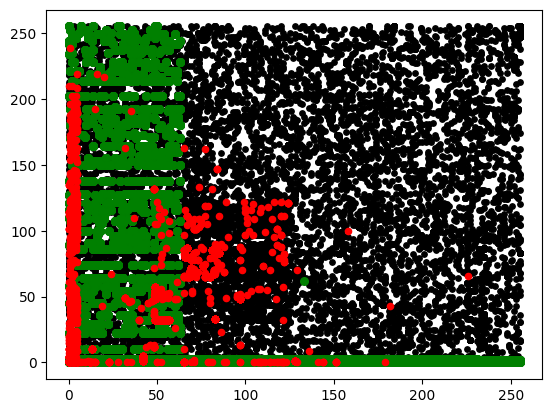

In [91]:
plt.scatter(X_train2.iloc[y_dbscan==-1, 0],X_train2.iloc[y_dbscan==-1, 1],s=15,  c='black')
plt.scatter(X_train2.iloc[y_dbscan==0, 0],X_train2.iloc[y_dbscan==0, 1],s=30,  c='green')
#plt.scatter(X_train2.iloc[y_dbscan==1, 0],X_train2.iloc[y_dbscan==1, 1],s=20,  c='blue')
plt.scatter(X_train2.iloc[y_dbscan==2, 0],X_train2.iloc[y_dbscan==2, 1],s=20,  c='red')
#plt.scatter(X_train2.iloc[y_dbscan==3, 0],X_train2.iloc[y_dbscan==3, 1],s=100,  c='pink')
#plt.scatter(X_train2.iloc[y_dbscan==3218, 0],X_train2.iloc[y_dbscan==3218, 1],s=200,  c='yellow')
#plt.scatter(X_train2.iloc[y_dbscan==62, 0],X_train2.iloc[y_dbscan==62, 1],s=200,  c='green')
#plt.scatter(X_train2.iloc[y_dbscan==10, 0],X_train2.iloc[y_dbscan==10, 1],s=200,  c='pink')
#plt.scatter(X_train2.iloc[y_dbscan==21, 0],X_train2.iloc[y_dbscan==21, 1],s=200,  c='silver')
#plt.scatter(X_train2.iloc[y_dbscan==184, 0],X_train2.iloc[y_dbscan==184, 1],s=200,  c='brown')
plt.show()

In [292]:
X_train2.iloc[y_dbscan==-1]

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
77130,132,189,16,123,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63929,0,0,2,100,10,20,217,16,119,116,...,0,0,0,0,0,0,0,0,0,0
28080,0,0,0,133,255,83,77,66,114,0,...,0,0,0,0,0,0,0,0,0,0
52332,209,53,127,114,241,95,35,94,23,55,...,0,0,0,0,0,0,0,0,0,0
59418,227,17,0,0,0,88,253,38,157,59,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24620,255,255,255,255,255,255,255,255,255,255,...,0,0,0,0,0,0,0,0,0,0
64162,227,60,0,0,0,76,71,33,125,146,...,0,0,0,0,0,0,0,0,0,0
65425,227,61,0,0,0,1,16,159,149,157,...,0,0,0,0,0,0,0,0,0,0
63609,60,123,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [272]:
X_train2.iloc[y_dbscan==0]

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
33222,39,150,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
44913,63,228,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
77130,132,189,16,123,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63234,75,108,98,99,13,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72701,40,225,150,167,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24480,226,66,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8181,68,65,84,65,13,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69730,0,0,0,13,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36936,5,22,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [273]:
X_train2.iloc[y_dbscan==1]

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
13261,66,80,83,33,32,52,57,32,66,80,...,0,0,0,0,0,0,0,0,0,0
2303,66,80,83,33,32,102,102,32,66,80,...,0,0,0,0,0,0,0,0,0,0
3319,66,80,83,33,32,49,102,32,66,80,...,0,0,0,0,0,0,0,0,0,0
35649,66,80,83,33,32,55,102,32,66,80,...,0,0,0,0,0,0,0,0,0,0
4740,66,80,83,33,32,54,56,32,66,80,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46687,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,0,0,0,0,0
16342,66,80,83,33,32,55,56,32,66,80,...,0,0,0,0,0,0,0,0,0,0
46376,66,80,83,33,32,54,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0
8919,66,80,83,33,32,51,57,32,66,80,...,0,0,0,0,0,0,0,0,0,0


In [250]:
X_train2.iloc[y_dbscan==2]

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
63234,75,108,98,99,13,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27433,3,45,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17351,0,4,29,165,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
65728,50,50,32,73,68,76,69,13,10,0,...,0,0,0,0,0,0,0,0,0,0
63629,0,0,0,13,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54418,42,2,0,3,0,10,0,1,0,6,...,0,0,0,0,0,0,0,0,0,0
16282,1,1,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24480,226,66,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8181,68,65,84,65,13,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [293]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=5, random_state=42)

dbscan = DBSCAN(eps=0.5, min_samples=5)
y_pred = dbscan.fit_predict(X)

ari = adjusted_rand_score(y, y_pred)
print("Adjusted Rand index:", ari)

Adjusted Rand index: 0.7020149449891828


In [96]:
X_train2.shape

(71892, 1500)

In [105]:
X_train2.iloc[0]

payload_byte_1        39
payload_byte_2       150
payload_byte_3         1
payload_byte_4         0
payload_byte_5         0
                    ... 
payload_byte_1496      0
payload_byte_1497      0
payload_byte_1498      0
payload_byte_1499      0
payload_byte_1500      0
Name: 33222, Length: 1500, dtype: int64

In [112]:
X_train2.iloc[2:4,:-1]

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1490,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499
77130,132,189,16,123,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63234,75,108,98,99,13,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
